In [2]:
print("hello world")

hello world


In [1]:
import sys
sys.modules.pop('feature_transformer', None)
sys.modules.pop('utils.data_quality', None)
sys.modules.pop('utils.stats_dataset', None)
sys.modules.pop('utils.algo_prediction', None)
sys.modules.pop('utils.models_and_metrics', None)

In [33]:
from utils.feature_loader import load_feature_lists
from utils.data_quality import nettoyer_nan_par_colonne
# from utils.data_quality import nettoyer_lignes_vides
import pandas as pd
df_groh = pd.read_excel(r"C:\Users\romai\Desktop\travail\Copie de BAZEA.xlsx")
# taux de Nan
# for col in df_groh.columns:
#     print(round(df_groh[col].isna().mean(),2),col, )
# df_groh,index_a_drop = nettoyer_lignes_vides(df_groh)
feature_lists = load_feature_lists("utils/features_grroh.json",available_columns = df_groh.columns)
features_grroh = df_groh[feature_lists["Liste_features_grroh"] + feature_lists["Liste_features_scan_radio"]]
features_etiology = df_groh[feature_lists["features_etiology"]]
features_death = df_groh[feature_lists["death"]]
features_oxygen = df_groh[feature_lists["oxygene"]]
# print(features_grroh.columns)


In [75]:
from utils.data_quality import nettoyer_lignes_vides
from utils.feature_transformer import transform_features
sys.modules.pop('utils.utils_grroh',None)
from utils.utils_grroh import construire_mapping_renommage,format_to_efraim,ensure_float_clip
feature_lists = load_feature_lists("utils/features_grroh.json",available_columns = df_groh.columns)
# oxygen
df_oxygen = df_groh[feature_lists["oxygene"]]
# death
df_death = df_groh[feature_lists['death']]
df_death = df_death.copy()
df_death[["DATEDECES","DSORTREA","DATSORTIEHOSP","DATADMHOSPI","DATADMREA"]] = df_death[["DATEDECES","DSORTREA","DATSORTIEHOSP","DATADMHOSPI","DATADMREA"]].apply(pd.to_datetime, errors="coerce")
df_death["death_days"] = (df_death['DATEDECES'] -  df_death['DATADMHOSPI']).dt.days
df_death["hosp_death"] = df_death["ETATSORTIEHOSP"] 
df_death["ICU_stay"] = (df_death['DSORTREA'] -  df_death['DATADMREA']).dt.days
df_death["hosp_stay"] = (df_death['DATSORTIEHOSP'] -  df_death['DATADMHOSPI']).dt.days
df_death["death_rea"]  =  df_death["ESORTREA"] 
df_death["death_90_days"]  =  (( df_death["ETATSORTIEHOSP"] == 1) | ( df_death["ESORTREA"] == 1))  | (df_death["death_days"].notna() & (df_death["death_days"] <= 90.0))

features_grroh = df_groh[feature_lists["Liste_features_grroh"] + feature_lists["Liste_features_scan_radio"]+ feature_lists["features_etiology"] ]
mapping_df = construire_mapping_renommage(feature_lists["Liste_features_grroh"] +feature_lists["Liste_features_scan_radio"] + feature_lists["features_etiology"] )
df_formatted = format_to_efraim(features_grroh, mapping_df)
df_renomme = ensure_float_clip(df_formatted)
df_nb = df_renomme.select_dtypes(include="number")
# _ = df_nb.hist(figsize=(10,8))
L_fill_mediane = ["Age"	,
                  "Time H-ICU"	,
                  "TIME SYMPTOMES-ICU",
                  "Time  DG-ICU",
                  "SOFA_score",
                  "Temp",
                  "Charlson_index",
                  "SaO2",
                  "PaO2/FiO2 VALUE VALUE",
                  "Resp_rate",
                  "Leukocytes",
                  "Quad_no"]
strategie_fill_nan = {
    col: "median" if col in L_fill_mediane else "zero"
    for col in df_renomme.columns
}
grroh_clean = nettoyer_nan_par_colonne(df_renomme,strategie_fill_nan)
grroh_clean["Hem_mal"]  = grroh_clean["Hem_mal"] .fillna(0)

grroh_clean_transform = transform_features(grroh_clean)#grroh_clean
grroh_clean_transform = grroh_clean_transform.drop(columns=['Leukocytes'])
# Enlever les non diag
L_diag = ['Bacterial infection', 'Viral infection',
'Invasive pulmonary aspergillosis', 'All fungus', 'Other fungal',
'Mucorales', 'Pneumocystis jirovecii infection',
'Cardiogenic pulmonary oedema', 'Disease-related infiltrates',
'Drug toxicity related', 'Other infection',
'Other non infectious causes']
L_features = [x for x in grroh_clean_transform if x not in L_diag]
grroh_diag = grroh_clean_transform[L_diag]

grroh_diag,index_a_drop = nettoyer_lignes_vides(grroh_diag)
grroh_clean_transform = grroh_clean_transform.drop(index=index_a_drop)
df_death = df_death.drop(index=index_a_drop)
df_oxygen = df_oxygen.drop(index=index_a_drop)
grroh_features = grroh_clean_transform[L_features]
grroh_clean_transform = pd.concat([grroh_features,grroh_diag],axis=1)

🔹 Age → NaN remplacés par la médiane (63.0)
🔹 Time H-ICU → NaN remplacés par la médiane (6.0)
🔹 TIME SYMPTOMES-ICU → NaN remplacés par la médiane (1.0)
🔹 Time  DG-ICU → NaN remplacés par la médiane (199.0)
🔹 Charlson_index → NaN remplacés par la médiane (5.0)
🔹 SOFA_score → NaN remplacés par la médiane (6.0)
🔹 Resp_rate → NaN remplacés par la médiane (30.0)
🔹 SaO2 → NaN remplacés par la médiane (0.92)
🔹 Temp → NaN remplacés par la médiane (38.1)
🔹 Leukocytes → NaN remplacés par la médiane (8.2)
🔹 Quad_no → NaN remplacés par la médiane (2.0)
🔹 PaO2/FiO2 VALUE VALUE → NaN remplacés par la médiane (149.0)

✅ Nettoyage terminé. NaN restants : 0
Nombre de lignes totalement vides : 1106


c:\Users\romai\Desktop\codes\respiratory_diagnostics\utils\feature_transformer.py:192: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.loc[df["GvHD"] >= 1,"GvHD"] = 1


In [71]:
df_death["death_days"].notna() & (df_death["death_days"] <= 90.0)

2       False
3       False
6        True
7        True
9       False
        ...  
4121    False
4122    False
4123    False
4128    False
4129    False
Name: death_days, Length: 3032, dtype: bool

In [76]:
df_death['death_days'],df_death['death_days'] <=90, df_death['death_90_days']

(2         NaN
 3       345.0
 6        77.0
 7        39.0
 9         NaN
         ...  
 4121      NaN
 4122      NaN
 4123      NaN
 4128      NaN
 4129      NaN
 Name: death_days, Length: 3032, dtype: float64,
 2       False
 3       False
 6        True
 7        True
 9       False
         ...  
 4121    False
 4122    False
 4123    False
 4128    False
 4129    False
 Name: death_days, Length: 3032, dtype: bool,
 2       False
 3       False
 6        True
 7        True
 9       False
         ...  
 4121     True
 4122    False
 4123    False
 4128    False
 4129     True
 Name: death_90_days, Length: 3032, dtype: bool)

In [105]:
grroh_clean_transform[['Septal_line',
       'Halo_sign', 'Disease_status_remission', 'Hypotension', 'Pleural_eff',
       'Excavation', 'Lymph_bulky', 'GGO', 'Nodules_any', 'Alveolar']].max(axis = 1).value_counts()/len(grroh_clean_transform)

1.0    0.94558
0.0    0.05442
Name: count, dtype: float64

In [141]:
grroh_diag.sum(axis=1).value_counts(), grroh_diag.sum(axis=1).value_counts() / len(grroh_diag)

(1    2782
 2     223
 3      27
 Name: count, dtype: int64,
 1    0.917546
 2    0.073549
 3    0.008905
 Name: count, dtype: float64)

In [142]:
grroh_features["Indication_prophy_pneumocystose_taken"].value_counts()

Indication_prophy_pneumocystose_taken
0.0    2672
1.0     360
Name: count, dtype: Int64

In [143]:
df_groh.columns

Index(['Study', 'PATIENT', 'CENTRE', 'SEXE', 'DATNAI', 'age', 'DATINC',
       'DATADMHOSPI', 'DATADMREA', 'DSORTREA',
       ...
       'Pathog√®ne.1.bis', 'Pathog√®ne.2.bis', 'Pathog√®ne.3.bis',
       'DIAGNOSTIC.DEF.1.x', 'DIAGNOSTIC.DEF.2.x', 'DIAGNOSTIC.DEF.3.x',
       'PATHOGENE.DEF.1', 'PATHOGENE.DEF.2', 'PATHOGENE.DEF.3',
       'Unnamed: 194'],
      dtype='object', length=195)

In [77]:
df_death['death_90_days'].value_counts(),df_death['death_90_days'].value_counts()/len(df_death)

(death_90_days
 False    1821
 True     1211
 Name: count, dtype: int64,
 death_90_days
 False    0.600594
 True     0.399406
 Name: count, dtype: float64)

In [41]:
for col in df_death.columns:
    print(df_death[col].value_counts(),df_death[col].value_counts()/len(df_death))

ETATSORTIEHOSP
0.0    1782
1.0    1201
Name: count, dtype: int64 ETATSORTIEHOSP
0.0    0.587731
1.0    0.396108
Name: count, dtype: float64
ESORTREA
0    2169
1     863
Name: count, dtype: int64 ESORTREA
0    0.715369
1    0.284631
Name: count, dtype: float64
DATEDECES
2017-02-13    5
2017-12-20    4
2017-02-03    3
2011-01-31    3
2016-12-17    3
             ..
2004-03-30    1
2005-06-14    1
2004-08-29    1
2005-03-12    1
2010-02-17    1
Name: count, Length: 563, dtype: int64 DATEDECES
2017-02-13    0.001649
2017-12-20    0.001319
2017-02-03    0.000989
2011-01-31    0.000989
2016-12-17    0.000989
                ...   
2004-03-30    0.000330
2005-06-14    0.000330
2004-08-29    0.000330
2005-03-12    0.000330
2010-02-17    0.000330
Name: count, Length: 563, dtype: float64
DSORTREA
2016-02-26    14
2016-04-20    13
2016-04-26    12
2016-02-18    12
2016-03-09    12
              ..
2005-10-06     1
2006-07-21     1
2006-11-08     1
2006-07-25     1
2006-04-26     1
Name: count, Le

In [25]:
#df_groh

In [109]:
df_groh["DATADMREA"] = pd.to_datetime(df_groh["DATADMREA"])
df_groh["DATADMHOSPI"] = pd.to_datetime(df_groh["DATADMHOSPI"])
df_groh["diff_jours"] = (
    df_groh["DATADMREA"] - df_groh["DATADMHOSPI"]
).dt.days
numeric_df = df_groh["diff_jours"]
medians = numeric_df.median()
q1 = numeric_df.quantile(0.25)
q3 = numeric_df.quantile(0.75)
print(medians,q1,q3)
len(numeric_df)

1.0 0.0 10.0


4138

In [8]:
pd.unique(df_formatted["Excavation"].dropna())

array([0., 1., 2.])

In [9]:
grroh_diag.iloc[1876]

Bacterial infection                 False
Viral infection                      True
Invasive pulmonary aspergillosis     True
All fungus                          False
Other fungal                        False
Mucorales                           False
Pneumocystis jirovecii infection    False
Cardiogenic pulmonary oedema        False
Disease-related infiltrates         False
Drug toxicity related               False
Other infection                     False
Other non infectious causes         False
Name: 2589, dtype: bool

# Efraim 

In [78]:
import pandas as pd
import numpy as np
from pathlib import Path

import json
import matplotlib.pyplot as plt
from utils.stats_dataset import analyser_variables_binaires
from utils.feature_transformer import transform_features, _convert_all_columns_to_numeric
from utils.data_quality import nettoyer_nan_par_colonne
from utils.data_quality import analyser_nan,nettoyer_lignes_vides,nettoyer_colonnes
from utils.feature_loader import load_feature_lists, load_diagnostic_feature_map
import sys
# loads the col
FEATURE_CONFIG_PATH = "utils/feature_columns.json"
feature_lists = load_feature_lists(FEATURE_CONFIG_PATH)
Liste_features_simple = feature_lists["Liste_features_simple"]
features_radiology_dysfunction = feature_lists["features_radiology_dysfunction"]
features_etiology = feature_lists["features_etiology"]
features_death = feature_lists["death"]
features_oxygen = feature_lists["oxygene"]

# Charger le fichier Excel
df = pd.read_excel(r"C:\Users\romai\Desktop\travail\EFRAIM3 JD VANCE.xlsx")


0.5379933042507863

In [79]:

# separer colonnes explicatives et etiology
df = df[df['Etiology_Undetermined cause_Definitive diagnosis'] != 1]
# features_etiology.remove('Etiology_Undetermined cause_Definitive diagnosis')

diagnostic_feature_map = load_diagnostic_feature_map(
    FEATURE_CONFIG_PATH,
    available_columns=df.columns,
    diagnoses = ["default"] #"Bacterial infection", # A changer pour bacterial !!! 
)
all_feature_columns = []
for columns_list in diagnostic_feature_map.values():
    for feature_name in columns_list:
        if feature_name not in all_feature_columns:
            all_feature_columns.append(feature_name)
Liste_features = all_feature_columns
df_col_utils = df[Liste_features]
df_category = df[features_etiology]
df_oxygen_efraim = df[features_oxygen]
df_oxygen_efraim['VNI'] = df_oxygen_efraim['HELMET'].astype(bool) |  df_oxygen_efraim['oxygen_strategy_NIV helmet_initiation date'].notna() |  df_oxygen_efraim['CPAP'].astype(bool)  |  df_oxygen_efraim['oxygen_strategy_NIV_initiation date'].notna()
df_oxygen_efraim = df_oxygen_efraim.drop(columns = ['HELMET',"CPAP",'oxygen_strategy_NIV helmet_initiation date','oxygen_strategy_NIV_initiation date'])
df_death_efraim = df[features_death]
df_death_efraim = df_death_efraim.copy()
df_death_efraim[['death_rea', 'death_90_days']] = df_death_efraim[['icu death', 'D90 DEATH']].rename({'icu death' : "death_rea",'D90 DEATH' :  "death_90_days"}, axis=1)

DIAGNOSTIC_FEATURES = diagnostic_feature_map
L_fill_mediane = ["Age"	,"Time H-ICU"	,"TIME SYMPTOMES-ICU","SOFA_score",
                  "Neutrophils","Temp","SpO2","PaO2/FiO2 VALUE VALUE","Resp_rate","Leukocytes","Quad_no","Charlson_index"]
strategie_fill_nan = {
    col: "median" if col in L_fill_mediane else "zero"
    for col in Liste_features
}
strategie_fill_nan["DG1"] = "str"
strategie_fill_nan["DG2"] = "str"
strategie_fill_nan["Sys_dis_spec"] = "str"
df_col_utils = nettoyer_nan_par_colonne(df_col_utils,strategie_fill_nan)
df_features_clean = transform_features(df_col_utils)
# resultats = analyser_nan(df_col_utils, top_n=3)
# resultats_y = analyser_nan(df_category, top_n=8)
df_category = nettoyer_colonnes(df_category)
df_cat_clean,index_a_drop = nettoyer_lignes_vides(df_category)
df_features_clean = df_features_clean.drop(index=index_a_drop)
df_death_efraim = df_death_efraim.drop(index=index_a_drop)
df_oxygen_efraim = df_oxygen_efraim.drop(index=index_a_drop)
# df_features_clean = _convert_all_columns_to_numeric(df_features_clean)
# format mapping_etiology[nvelle_col] = [old_col1,old_cold2 ,...]
mapping_etiology ={
                    'Bacterial infection' :['Bacterial infection'] ,
                    'Viral infection' :['Viral infection'] ,
                    'Invasive pulmonary aspergillosis' :['Invasive pulmonary aspergillosis'] ,
                    'All fungus' : ["Other fungal ",'Mucorales'],
                    'Other fungal' :["Other fungal "] ,
                    'Mucorales' : ['Mucorales'],
                    'Pneumocystis jirovecii infection' :[ 'Pneumocystis jirovecii infection'],
                    'Cardiogenic pulmonary oedema' : ['Cardiogenic pulmonary oedema'],
                    'Disease-related infiltrates':['Disease-related infiltrates'],
                    'Drug toxicity related' : ['Drug toxicity related'],
                    'Other infection' : ['Other infection '],
                    'Other non infectious causes': ['Other non infectious causes','Transfusion-related acute lung injury'],
                #    'Undetermined cause':['Undetermined cause' ]
                    }
from utils.data_quality import fusionner_labels
df_labels_fusion = fusionner_labels(df_cat_clean, mapping_etiology, mode="max")


C:\Users\romai\AppData\Local\Temp\ipykernel_22208\1829457014.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_oxygen_efraim['VNI'] = df_oxygen_efraim['HELMET'].astype(bool) |  df_oxygen_efraim['oxygen_strategy_NIV helmet_initiation date'].notna() |  df_oxygen_efraim['CPAP'].astype(bool)  |  df_oxygen_efraim['oxygen_strategy_NIV_initiation date'].notna()


🔹 Age → NaN remplacés par la médiane (64.0)
🔹 Time H-ICU → NaN remplacés par la médiane (2.0)
🔹 TIME SYMPTOMES-ICU → NaN remplacés par la médiane (2.0)
🔹 Charlson_index → NaN remplacés par la médiane (5.0)
🔹 SOFA_score → NaN remplacés par la médiane (7.0)
🔹 Resp_rate → NaN remplacés par la médiane (30.0)
🔹 SpO2 → NaN remplacés par la médiane (92.0)
🔹 Temp → NaN remplacés par la médiane (37.3)
🔹 PaO2/FiO2 VALUE VALUE → NaN remplacés par la médiane (88.0)
🔹 Neutrophils → NaN remplacés par la médiane (7.17)
🔹 Leukocytes → NaN remplacés par la médiane (9.51)
🔹 Quad_no → NaN remplacés par la médiane (3.0)
⚠️ Colonne 'DG1' absente du DataFrame, ignorée.
⚠️ Colonne 'DG2' absente du DataFrame, ignorée.
⚠️ Colonne 'Sys_dis_spec' absente du DataFrame, ignorée.

✅ Nettoyage terminé. NaN restants : 0
Nombre de lignes totalement vides : 3055


In [19]:
df_features_clean.iloc[0]

Sex                                               1.0
Time H-ICU                                   0.947368
TIME SYMPTOMES-ICU                           0.947368
Time  DG-ICU                                 0.989011
GvHD                                              0.0
Sys_dis                                           0.0
Solid_tumor                                       1.0
Organ_transpl                                     0.0
Chemotherapy                                      1.0
Ibr_Flu_Met                                       0.0
Immuno_drugs                                      0.0
Tar_ther                                          0.0
Immunotherapy                                     0.0
Carttcells                                        0.0
Steroids_YN                                       0.0
Charlson_index                                    3.0
Prophylaxis_antifungal                            0.0
Prophylaxis_bacterial                             0.0
Prophylaxis_viral           

In [ ]:
df_features_clean['GGO'].value_counts()

GGO
1.0    4470
0.0    2067
Name: count, dtype: Int64

6802

In [99]:
for col in df_oxygen_efraim.columns:
    print(df_oxygen_efraim[col].value_counts(),df_oxygen_efraim[col].value_counts()/len(df_oxygen_efraim))

RRT
0    5118
1    1220
       14
Name: count, dtype: int64 RRT
0    0.804717
1    0.191824
     0.002201
Name: count, dtype: float64
IMV_applicable_YN
1    3783
0    2566
        8
Name: count, dtype: int64 IMV_applicable_YN
1    0.594811
0    0.403459
     0.001258
Name: count, dtype: float64
HFNO
0.0    3682
1.0    2678
Name: count, dtype: int64 HFNO
0.0    0.578931
1.0    0.421069
Name: count, dtype: float64
Vasopressors
1    3712
0    2638
        5
Name: count, dtype: int64 Vasopressors
1    0.583648
0    0.414780
     0.000786
Name: count, dtype: float64
VNI
False    4538
True     1822
Name: count, dtype: int64 VNI
False    0.713522
True     0.286478
Name: count, dtype: float64


In [ ]:
df["ICU_adm_date"] = pd.to_datetime(df["ICU_adm_date"])
df["Hos_adm_date"] = pd.to_datetime(df["Hos_adm_date"])
df["diff_jours"] = (
    df["ICU_adm_date"] - df["Hos_adm_date"]
).dt.days
numeric_df = df["diff_jours"]

# numeric_df = df_death_efraim[df_death_efraim["HOSPITAL   LOS"] > 1]["HOSPITAL   LOS"]
medians = numeric_df.median()
q1 = numeric_df.quantile(0.25)
q3 = numeric_df.quantile(0.75)
print(len(numeric_df[numeric_df>=1]),len(numeric_df[numeric_df>=1])/len(numeric_df))
print(medians,q1,q3)

6248 0.6636218799787573
2.0 0.0 9.0


: 

In [111]:
df['Etiology_Undetermined cause_Definitive diagnosis'].value_counts()

Etiology_Undetermined cause_Definitive diagnosis
0.0    2517
1.0     442
Name: count, dtype: int64

In [13]:
df_labels_fusion[df_labels_fusion.sum(axis=1) == 11]

,Bacterial infection,Viral infection,Invasive pulmonary aspergillosis,All fungus,Other fungal,Mucorales,Pneumocystis jirovecii infection,Cardiogenic pulmonary oedema,Disease-related infiltrates,Drug toxicity related,Other infection,Other non infectious causes
6152,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


# Comparasion des valeurs 

In [ ]:
df

np.float64(94.0)

In [18]:
sys.modules.pop('utils.data_quality',None)
from utils.data_quality import compare_columns
df_with_diag = pd.concat([df_features_clean,df_labels_fusion],axis=1)

compare_columns(df_with_diag,grroh_clean_transform)

Colonnes uniquement dans df1 :
set()

Colonnes uniquement dans df2 :
set()


In [ ]:
sys.modules.pop("utils.data_quality",None)
from utils.data_quality import plot_column_histograms

fig, axes = plot_column_histograms(
    df_left=df_with_diag,
    df_right=grroh_clean_transform,
    columns=grroh_clean_transform.columns,
    bins=40,
    label_left="Efraim",
    label_right="Grroh",
    suptitle="difference of distributions"
)
plt.show()

In [21]:
grroh_features


,Time H-ICU,TIME SYMPTOMES-ICU,Time DG-ICU,HSCT_BMT_Allograft,HSCT_BMT_Autograft,Sys_dis,Solid_tumor,Organ_transpl,Immuno_drugs,Steroids_YN,...,Hem_mal_CML,Hem_mal_MDS,Hem_mal_other,SOFA_scaled,Resp_severity,Temp_gravité,Leukostase,Indication_prophy_anti_fun,Indication_prophy_pneumocystose_taken,Indication_prophy_pneumocystose_not_taken
2,0.666667,NaN,0.916667,0.0,0.0,0,0,0,0.0,1.0,...,0.0,0.0,0.0,0.041667,<NA>,0.0,0.0,0.0,<NA>,<NA>
3,0.000000,0.900000,0.000000,0.0,0.0,0,0,0,0.0,1.0,...,0.0,0.0,0.0,0.125000,0.0,0.6,1.0,1.0,<NA>,<NA>
6,0.983051,0.000000,0.983051,0.0,0.0,0,0,0,0.0,1.0,...,0.0,0.0,0.0,0.125000,1.0,0.6,0.0,0.0,1.0,0.0
7,0.000000,0.500000,0.997260,0.0,0.0,0,0,0,0.0,0.0,...,0.0,0.0,0.0,NaN,1.0,0.6,0.0,0.0,1.0,0.0
9,0.666667,0.000000,0.994764,0.0,0.0,0,0,0,0.0,0.0,...,0.0,0.0,0.0,0.250000,0.0,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4121,0.916667,0.500000,0.916667,0.0,NaN,0,0,1,1.0,NaN,...,0.0,0.0,0.0,0.625000,<NA>,1.0,0.0,0.0,<NA>,<NA>
4122,0.500000,0.857143,0.997260,0.0,NaN,0,0,1,1.0,0.0,...,0.0,0.0,0.0,0.250000,<NA>,0.6,0.0,0.0,1.0,0.0
4123,0.916667,0.000000,0.997260,0.0,NaN,0,0,1,1.0,0.0,...,0.0,0.0,0.0,0.166667,<NA>,0.6,0.0,0.0,1.0,0.0
4128,0.000000,0.916667,0.997085,0.0,NaN,0,0,1,1.0,1.0,...,<NA>,<NA>,<NA>,0.250000,<NA>,0.6,<NA>,0.0,<NA>,<NA>


In [15]:
grroh_features.iloc[2].values

array([np.float64(0.9830508474576272), np.float64(0.0),
       np.float64(0.9830508474576272), np.float64(0.0), np.float64(0.0),
       np.int64(0), np.int64(0), np.int64(0), np.float64(0.0),
       np.float64(1.0), np.float64(nan), np.float64(1.0), np.float64(3.0),
       np.float64(0.0), np.float64(0.98), np.float64(0.0),
       np.float64(2.0), np.float64(0.0), np.float64(0.0), np.float64(1.0),
       np.float64(1.0), np.float64(0.0), np.float64(0.0), np.float64(0.0),
       np.float64(1.0), np.float64(1.0), np.float64(1.0), False,
       np.False_, np.False_, np.True_, np.float64(156.1343154),
       np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0),
       np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0),
       np.float64(0.5531914893617021), np.float64(0.0), np.float64(0.0),
       np.float64(1.0), np.float64(0.0), np.float64(0.0), np.float64(0.0),
       np.float64(0.0), np.float64(0.0), np.float64(0.0),
       np.float64(0.125), np.float64(1.0), np

# performance sur les données du grroh

In [96]:
for i in grroh_features.iloc[2].values:
    print(i, " , ")


0.9830508474576272  , 
0.0  , 
0.9830508474576272  , 
0.0  , 
0.0  , 
0  , 
0  , 
0  , 
0.0  , 
1.0  , 
0.0  , 
1.0  , 
3.0  , 
0.0  , 
0.98  , 
0.0  , 
2.0  , 
0.0  , 
0.0  , 
1.0  , 
1.0  , 
0.0  , 
0.0  , 
0.0  , 
1.0  , 
1.0  , 
1.0  , 
False  , 
False  , 
False  , 
True  , 
156.1343154  , 
0  , 
0  , 
0  , 
0  , 
0  , 
0  , 
0  , 
0  , 
0  , 
0  , 
0.5531914893617021  , 
0.0  , 
0.0  , 
1.0  , 
0.0  , 
0.0  , 
0.0  , 
0.0  , 
0.0  , 
0.0  , 
0.125  , 
1.0  , 
0.6  , 
0.0  , 
0.0  , 
1.0  , 
0.0  , 


In [93]:
list(grroh_features.columns)

['Time H-ICU',
 'TIME SYMPTOMES-ICU',
 'Time  DG-ICU',
 'HSCT_BMT_Allograft',
 'HSCT_BMT_Autograft',
 'Sys_dis',
 'Solid_tumor',
 'Organ_transpl',
 'Immuno_drugs',
 'Steroids_YN',
 'Prophylaxis_antifungal',
 'Prophylaxis_viral',
 'Charlson_index',
 'Hemoptysis',
 'SaO2',
 'Neutropenie',
 'Quad_no',
 'Septal_line',
 'Halo_sign',
 'Disease_status_remission',
 'Hypotension',
 'Pleural_eff',
 'Excavation',
 'Lymph_bulky',
 'GGO',
 'Nodules_any',
 'Alveolar',
 'GvHD',
 'Ibr_Flu_Met',
 'Sex',
 'Chemotherapy',
 'PaO2/FiO2 VALUE VALUE',
 'SOFA_Nervous',
 'Tar_ther',
 'Immunotherapy',
 'Carttcells',
 'Prophylaxis_bacterial',
 'Vaccins#Flu',
 'Vaccins#COVID',
 'Vaccins#Other',
 'Disease_status_inaugural',
 'Disease_status_evolutive',
 'Age_scaled',
 'Hem_mal_AML',
 'Hem_mal_ALL',
 'Hem_mal_Non_hodgkin_lymphoma',
 'Hem_mal_myeloma',
 'Hem_mal_hodgkin_lymphoma',
 'Hem_mal_CLL',
 'Hem_mal_CML',
 'Hem_mal_MDS',
 'Hem_mal_other',
 'SOFA_scaled',
 'Resp_severity',
 'Temp_gravité',
 'Leukostase',
 'Ind

In [ ]:
from utils.saved_model_inference import predict_all_saved_models

results = predict_all_saved_models(
    feature_values=grroh_features.iloc[2].values,
    feature_names=list(grroh_features.columns),
)
results,grroh_diag.iloc[2]

({'All fungus': {'diagnostic': 'All fungus',
   'model_path': 'C:\\Users\\romai\\Desktop\\codes\\respiratory_diagnostics\\models\\All_fungus.joblib',
   'probability': 0.09333333333333334,
   'threshold': 0.1,
   'prediction': 0},
  'Bacterial infection': {'diagnostic': 'Bacterial infection',
   'model_path': 'C:\\Users\\romai\\Desktop\\codes\\respiratory_diagnostics\\models\\Bacterial_infection.joblib',
   'probability': 0.3959052982030832,
   'threshold': 0.4721612533458751,
   'prediction': 0},
  'Cardiogenic pulmonary oedema': {'diagnostic': 'Cardiogenic pulmonary oedema',
   'model_path': 'C:\\Users\\romai\\Desktop\\codes\\respiratory_diagnostics\\models\\Cardiogenic_pulmonary_oedema.joblib',
   'probability': 0.40577494903143413,
   'threshold': 0.5026613410986225,
   'prediction': 0},
  'Disease-related infiltrates': {'diagnostic': 'Disease-related infiltrates',
   'model_path': 'C:\\Users\\romai\\Desktop\\codes\\respiratory_diagnostics\\models\\Disease_related_infiltrates.jobli

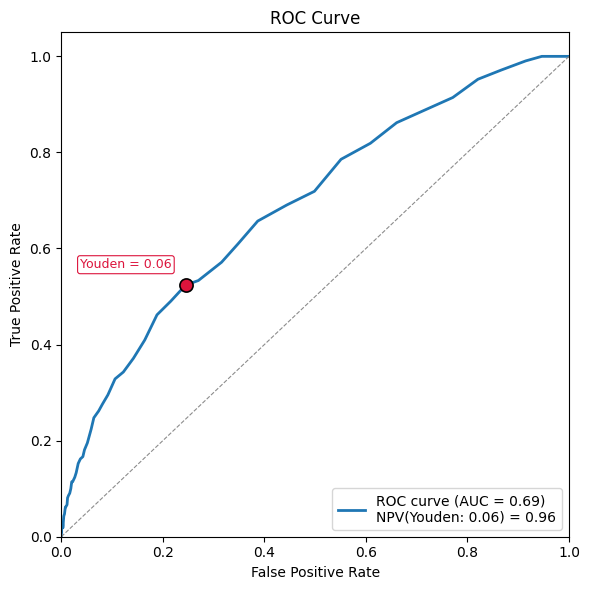

ROC AUC = 0.69
Negative Predictive Value youden: 0.9538793103448275 threshold 0.06333333333333334
==== Pneumocystis jirovecii infection (split fourni) ====
Monte Carlo 1/10 (seed=42)

📊 Répartition des classes : pos=0.052, neg=0.948
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

Monte Carlo 2/10 (seed=43)

📊 Répartition des classes : pos=0.052, neg=0.948
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

Monte Carlo 3/10 (seed=44)

📊 Répartition des classes : pos=0.052, neg=0.948
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

Monte Carlo 4/10 (seed=45)

📊 Répartition des classes : pos=0.052, neg=0.948
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

Monte Carlo 5/10 (seed=46)

📊 Répartition des classes : pos=0.052, neg=0.948
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing


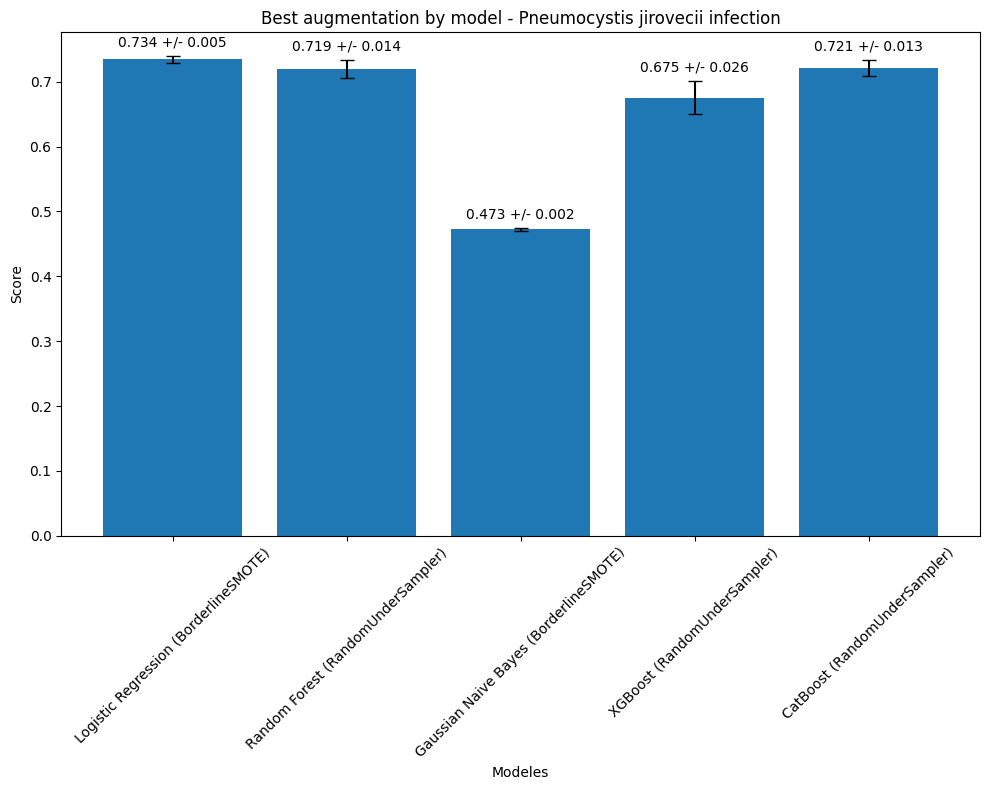


Courbes ROC des meilleures augmentations par modele :
- Logistic Regression (BorderlineSMOTE) - roc_auc moyen = 0.7344 +/- 0.0048 | seuil Youden = 0.2183
- Random Forest (RandomUnderSampler) - roc_auc moyen = 0.7193 +/- 0.0135 | seuil Youden = 0.5233
- Gaussian Naive Bayes (BorderlineSMOTE) - roc_auc moyen = 0.4725 +/- 0.0020 | seuil Youden = 0.0000
- XGBoost (RandomUnderSampler) - roc_auc moyen = 0.6752 +/- 0.0255 | seuil Youden = 0.8976
- CatBoost (RandomUnderSampler) - roc_auc moyen = 0.7212 +/- 0.0130 | seuil Youden = 0.5165


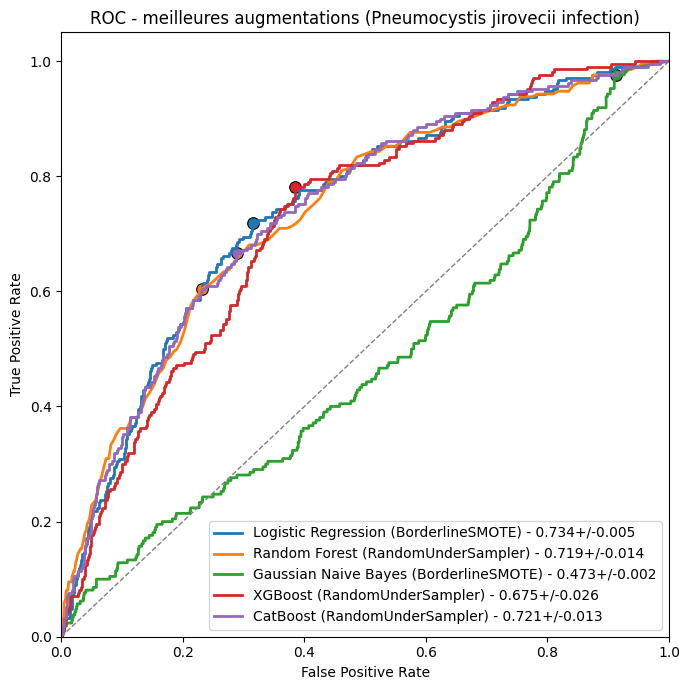

{'score': 0.7432823731902399,
 'score_mean': 0.7343817285950525,
 'score_std': 0.004838976495944194,
 'model_name': 'Logistic Regression',
 'augmentation_name': 'BorderlineSMOTE',
 'pipe_train': Pipeline(steps=[('scaler',
                  AutoStandardScaler(colonnes_numeriques=['Sex', 'Time H-ICU',
                                                          'TIME SYMPTOMES-ICU',
                                                          'Time  DG-ICU', 'GvHD',
                                                          'Sys_dis',
                                                          'Solid_tumor',
                                                          'Organ_transpl',
                                                          'Chemotherapy',
                                                          'Ibr_Flu_Met',
                                                          'Immuno_drugs',
                                                          'Tar_ther',
                             

In [32]:
from utils.model_saving import save_model, load_model
from utils.validation import validation_save
import os 
diagnostique = 'Pneumocystis jirovecii infection'
save_dir = r"C:\Users\romai\Desktop\travail\avancement\model_grid_search\\"
# for diagnostique in grroh_diag.columns:
model_loaded = load_model(diagnostic =diagnostique,
                    model_dir = os.getcwd() + r'\models\\'
                    )
# print(model_loaded["pipe_inference"].named_steps["scaler"].colonnes_numeriques)
validation_save(diagnostique,
                    save_dir,
                    
                    loaded = model_loaded,
                    grroh_features = grroh_features,
                    grroh_diag = grroh_diag,
                    df_features_clean = df_features_clean,
                    df_labels_fusion = df_labels_fusion
                    )


In [37]:
y_test.shape

(3032,)

# Visualisation des relations entre variables

In [ ]:
from utils.stats_dataset import analyser_variables_binaires
from utils.visualisation import plot_multilabel_network_matplotlib
analyser_variables_binaires(grroh_diag)
plot_multilabel_network_matplotlib(grroh_diag,normalize="percent",edge_threshold=0.5)

# Description des bases 
Faire bien attention a remettre le traitement des NaN et enlever les NaN pour le calcul des modèles.

In [46]:
sys.modules.pop('utils.stats_dataset')
from utils.stats_dataset import descript_data
df_outcome = pd.concat([df_features_clean,df_death_efraim],axis=1)
resume = descript_data(df_labels_fusion,non_binary_only=False,paper_format=True,save_path=r"C:\Users\romai\Desktop\travail\avancement\paper\efraim_labels_description.xlsx")


                            Variable     N   Mediane [Q1-Q3]  \
3                         All fungus  6802  0.00 [0.00-0.00]   
0                Bacterial infection  6802  0.00 [0.00-1.00]   
7       Cardiogenic pulmonary oedema  6802  0.00 [0.00-0.00]   
8        Disease-related infiltrates  6802  0.00 [0.00-0.00]   
9              Drug toxicity related  6802  0.00 [0.00-0.00]   
2   Invasive pulmonary aspergillosis  6802  0.00 [0.00-0.00]   
5                          Mucorales  6802  0.00 [0.00-0.00]   
4                       Other fungal  6802  0.00 [0.00-0.00]   
10                   Other infection  6802  0.00 [0.00-0.00]   
11       Other non infectious causes  6802  0.00 [0.00-1.00]   
6   Pneumocystis jirovecii infection  6802  0.00 [0.00-0.00]   
12                Undetermined cause  6802  0.00 [0.00-0.00]   
1                    Viral infection  6802  0.00 [0.00-1.00]   

   Donnees manquantes (%) Positive rate (%) Effectif positif  
3                    0.00              5

In [55]:
# sys.modules.pop('utils.stats_dataset')
from utils.stats_dataset import descript_data
df_outcome = pd.concat([grroh_features,df_death[["death_90_days","death_rea"]]],axis=1)
resume = descript_data(grroh_diag,non_binary_only=False,paper_format=True,save_path=r"C:\Users\romai\Desktop\travail\avancement\paper\grroh_labels_description.xlsx")


                            Variable     N   Mediane [Q1-Q3]  \
3                         All fungus  3191  0.00 [0.00-0.00]   
0                Bacterial infection  3191  0.00 [0.00-1.00]   
7       Cardiogenic pulmonary oedema  3191  0.00 [0.00-0.00]   
8        Disease-related infiltrates  3191  0.00 [0.00-0.00]   
9              Drug toxicity related  3191  0.00 [0.00-0.00]   
2   Invasive pulmonary aspergillosis  3191  0.00 [0.00-0.00]   
5                          Mucorales  3191  0.00 [0.00-0.00]   
4                       Other fungal  3191  0.00 [0.00-0.00]   
10                   Other infection  3191  0.00 [0.00-0.00]   
11       Other non infectious causes  3191  0.00 [0.00-0.00]   
6   Pneumocystis jirovecii infection  3191  0.00 [0.00-0.00]   
12                Undetermined cause  3191  0.00 [0.00-0.00]   
1                    Viral infection  3191  0.00 [0.00-0.00]   

   Donnees manquantes (%) Positive rate (%) Effectif positif  
3                    0.00              4

In [23]:
resume.columns

Index(['Variable', 'N', 'Effectif sans NA', 'Mediane [Q1-Q3]',
       'Donnees manquantes (%)', 'Positive rate (%)'],
      dtype='object')

# Analyse PCA

In [88]:
from utils.data_quality import fusionner_labels
labels_efraim = df_labels_fusion
labels_grroh = grroh_diag
features_efraim = df_features_clean
features_grroh = grroh_features
mapping_maladie_sous_jacente ={
    'Hematology' :['Hem_mal_ALL', 'Hem_mal_Non_hodgkin_lymphoma', 'Hem_mal_myeloma',
        'Hem_mal_hodgkin_lymphoma', 'Hem_mal_CLL', 'Hem_mal_CML', 'Hem_mal_MDS',
        'Hem_mal_other', 'HSCT_BMT_Autograft', 'HSCT_BMT_Allograft', 'Leukostase'] ,
    'greffe' : ['Organ_transpl'],
    'Oncology' : ['Solid_tumor', 'Chemotherapy'],
    'Med' : ['Ibr_Flu_Met', 'Tar_ther', 'Immunotherapy', 'Carttcells', 'Steroids_YN']
                    }
df_condition = fusionner_labels(features_efraim, mapping_maladie_sous_jacente, mode="max")
df_condition['Other'] = 1 - df_condition[['Hematology', 'greffe', 'Oncology', 'Med']].max(axis =1)
# order = hemato > greffe > médicaments > onco 
df_condition_ordered = df_condition.copy()
def remplace_ordre(df,col1,col2):
    df[col2] = df[col2] * (1 - df[col1])
remplace_ordre(df_condition_ordered,'Hematology', 'greffe')
remplace_ordre(df_condition_ordered,'Hematology', 'Oncology')
remplace_ordre(df_condition_ordered,'Hematology', 'Med')
remplace_ordre(df_condition_ordered,'greffe', 'Oncology',)
remplace_ordre(df_condition_ordered, 'greffe', 'Med')
remplace_ordre(df_condition_ordered,'Med', 'Oncology')
test = df_condition_ordered.sum(axis=1).value_counts()

In [86]:
for i,x in enumerate(features_grroh.columns):
    print(i,x)

0 Time H-ICU
1 TIME SYMPTOMES-ICU
2 Time  DG-ICU
3 HSCT_BMT_Allograft
4 HSCT_BMT_Autograft
5 Sys_dis
6 Solid_tumor
7 Organ_transpl
8 Immuno_drugs
9 Steroids_YN
10 Prophylaxis_antifungal
11 Prophylaxis_viral
12 Charlson_index
13 Hemoptysis
14 SaO2
15 Neutropenie
16 Quad_no
17 Septal_line
18 Halo_sign
19 Disease_status_remission
20 Hypotension
21 Pleural_eff
22 Excavation
23 Lymph_bulky
24 GGO
25 Nodules_any
26 Alveolar
27 GvHD
28 Ibr_Flu_Met
29 Sex
30 Chemotherapy
31 PaO2/FiO2 VALUE VALUE
32 SOFA_Nervous
33 Tar_ther
34 Immunotherapy
35 Carttcells
36 Prophylaxis_bacterial
37 Vaccins#Flu
38 Vaccins#COVID
39 Vaccins#Other
40 Disease_status_inaugural
41 Disease_status_evolutive
42 Age_scaled
43 Hem_mal_AML
44 Hem_mal_ALL
45 Hem_mal_Non_hodgkin_lymphoma
46 Hem_mal_myeloma
47 Hem_mal_hodgkin_lymphoma
48 Hem_mal_CLL
49 Hem_mal_CML
50 Hem_mal_MDS
51 Hem_mal_other
52 SOFA_scaled
53 Resp_severity
54 Temp_gravité
55 Leukostase
56 Indication_prophy_anti_fun
57 Indication_prophy_pneumocystose_taken


In [ ]:
sys.modules.pop('utils.pca',None)
sys.modules.pop('utils.pca_ui',None)
from utils.pca import PCA
from utils.pca_ui import show_pca_widget
# PCA(df_cat_clean, df_features_clean, max_points_per_label=100, sigma=2.0)
pca_ui_df = pd.concat([features_efraim, df_condition_ordered], axis=1)
show_pca_widget(pca_ui_df)

# Correspondance analysis

In [94]:
labels_taken = labels_efraim
for x in labels_taken.columns:
    print(x,len(labels_taken[labels_taken[x] == 1]))

Bacterial infection 2771
Viral infection 1837
Invasive pulmonary aspergillosis 328
All fungus 342
Other fungal 264
Mucorales 88
Pneumocystis jirovecii infection 333
Cardiogenic pulmonary oedema 841
Disease-related infiltrates 774
Drug toxicity related 264
Other infection 236
Other non infectious causes 1998


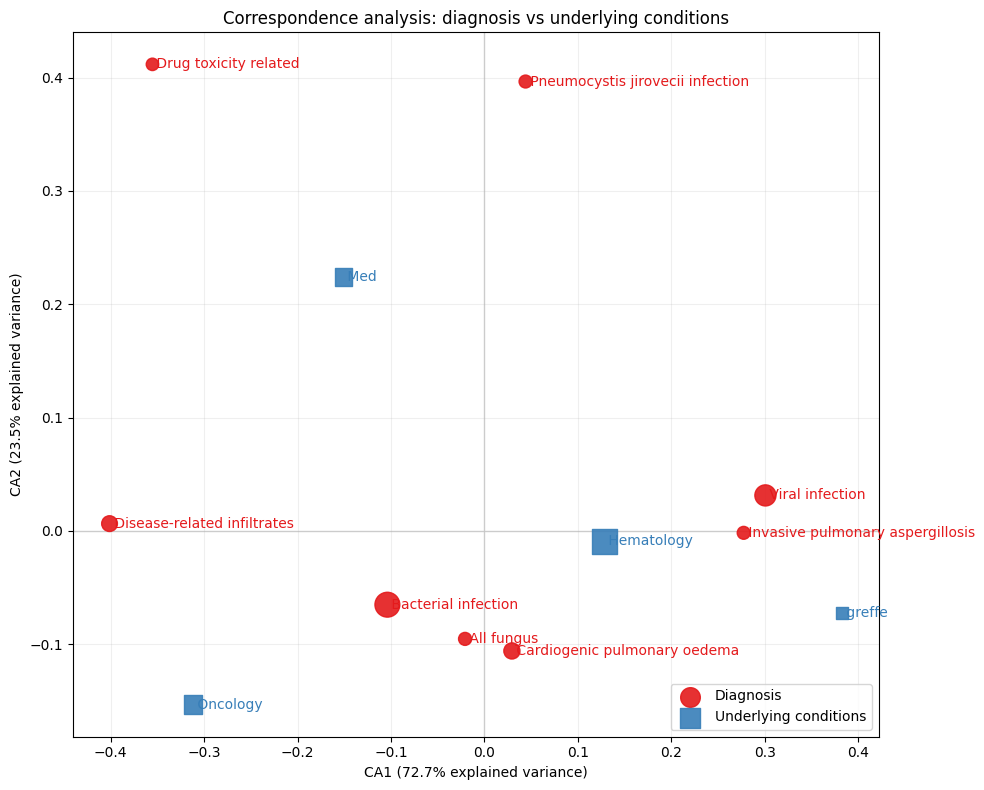

,CA1,CA2
Hematology,0.128477,-0.009196
greffe,0.383014,-0.072539
Oncology,-0.311949,-0.153311
Med,-0.151058,0.224177


In [92]:
sys.modules.pop('utils.correspondence_analysis',None)
from utils.correspondence_analysis import correspondence_analysis_from_dataframe
df_with_condition = pd.concat([features_efraim, labels_efraim,df_condition_ordered], axis=1)
df_with_condition = df_with_condition.drop(columns = ['Mucorales','Other fungal','Other infection','Other non infectious causes','Other'])
result = correspondence_analysis_from_dataframe(
    df=df_with_condition,
    diagnosis_columns=labels_efraim.drop(columns = ['Mucorales','Other fungal','Other infection','Other non infectious causes']).columns,
    underlying_condition_columns=df_condition.drop(columns = ['Other']).columns,
)

result["contingency_table"]
result["row_coordinates"]
result["column_coordinates"]

In [40]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    df_condition_ordered, labels_efraim, test_size=0.2, random_state=42)
from catboost import CatBoostClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import f1_score, hamming_loss

# Modèle de base rapide
base_model = CatBoostClassifier(
    iterations=100,
    depth=6,
    learning_rate=0.1,
    verbose=0,
)

# Wrapper multilabel
model = MultiOutputClassifier(base_model)

# Entraînement
model.fit(X_train, y_train)

# Prédictions
y_pred = model.predict(X_test)

# Évaluation
f1_macro = f1_score(y_test, y_pred, average="macro")
f1_micro = f1_score(y_test, y_pred, average="micro")
hamming = hamming_loss(y_test, y_pred)

print("F1 macro :", f1_macro)
print("F1 micro :", f1_micro)
print("Hamming loss :", hamming)

F1 macro : 0.028530314743726453
F1 micro : 0.08325709057639524
Hamming loss : 0.13128930817610063


In [25]:
22/30 * 3600

2640.0

In [26]:
df_condition_ordered.head()

,Hematology,greffe,Oncology,Medoc,Other
2,0.0,0.0,1.0,0.0,0.0
3,0.0,0.0,0.0,0.0,1.0
4,1.0,0.0,0.0,0.0,0.0
5,0.0,1.0,0.0,0.0,0.0
6,1.0,0.0,0.0,0.0,0.0


In [28]:
import pandas as pd

from utils.pca_ui import show_pca_widget

pca_ui_df = pd.concat([features_efraim, labels_efraim], axis=1)
show_pca_widget(pca_ui_df)